0. Imports + chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/dataset_delivery_time_clean.csv")  

num_cols = ["Distance_km", "Time_taken(min)"]
cat_cols = ["Weatherconditions", "Road_traffic_density", "Type_of_vehicle"]

1. Analyse descriptive (moyenne, médiane, écart-type + fréquences)

                      mean     median       std
Distance_km       9.720614   9.193021  5.603346
Time_taken(min)  26.311394  26.000000  9.380397
Weatherconditions
Fog           7578
Stormy        6970
Cloudy        6929
Sandstorms    6902
Windy         6830
Sunny         6725
Name: count, dtype: int64 

Road_traffic_density
Low       14747
Jam       13036
Medium    10083
High       4068
Name: count, dtype: int64 

Type_of_vehicle
motorcycle          24382
scooter             14024
electric_scooter     3468
bicycle                60
Name: count, dtype: int64 



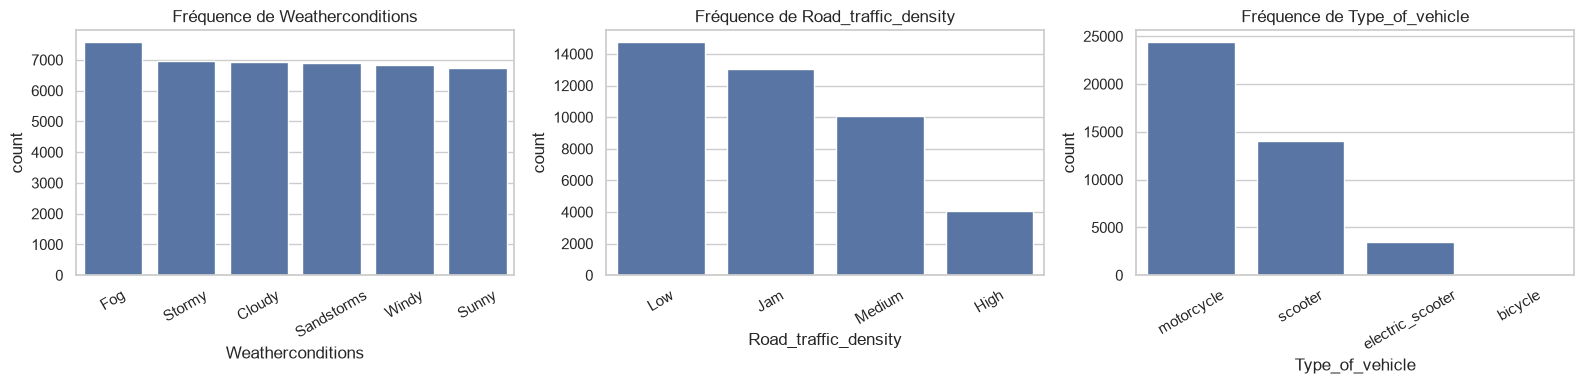

In [2]:
stats = df[num_cols].agg(["mean", "median", "std"]).T
print(stats)

for c in cat_cols:
    print(df[c].value_counts(), "\n")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, cat_cols):
    sns.countplot(data=df, x=c, order=df[c].value_counts().index, ax=ax)
    ax.set_title(f"Fréquence de {c}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

2. Distribution de la variable cible

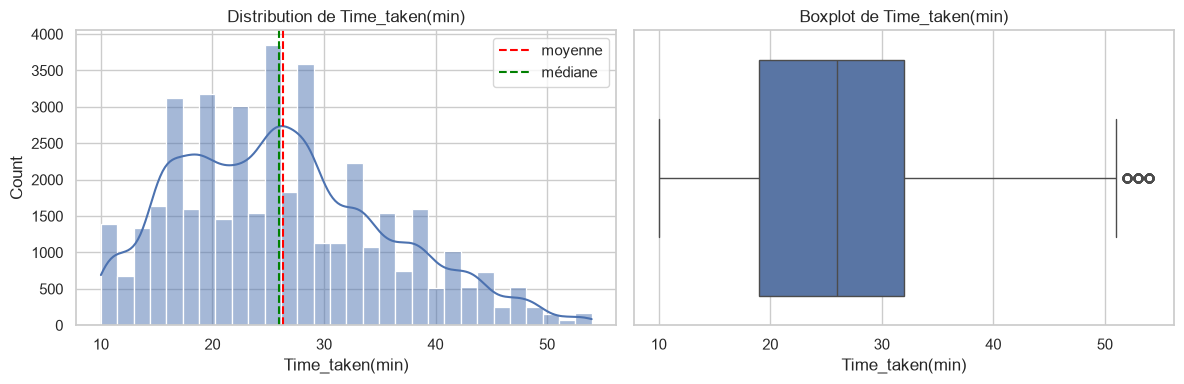

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Time_taken(min)"], kde=True, bins=30, ax=axes[0])
axes[0].axvline(df["Time_taken(min)"].mean(), color="red", ls="--", label="moyenne")
axes[0].axvline(df["Time_taken(min)"].median(), color="green", ls="--", label="médiane")
axes[0].legend()
axes[0].set_title("Distribution de Time_taken(min)")

sns.boxplot(x=df["Time_taken(min)"], ax=axes[1])
axes[1].set_title("Boxplot de Time_taken(min)")
plt.tight_layout()
plt.show()

3. Relation cible ↔ chaque variable explicative

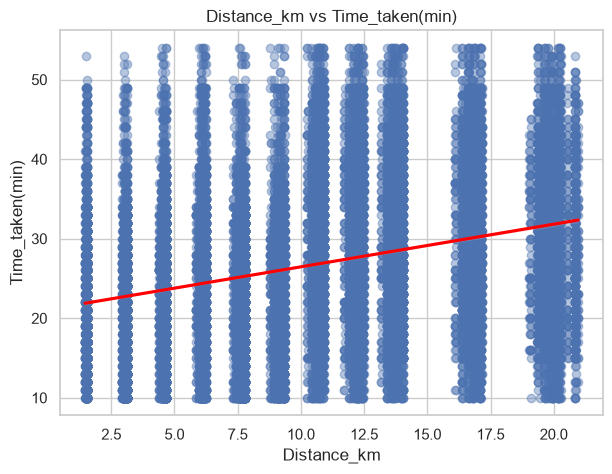

In [4]:
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x="Distance_km", y="Time_taken(min)",
            scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
plt.title("Distance_km vs Time_taken(min)")
plt.show()

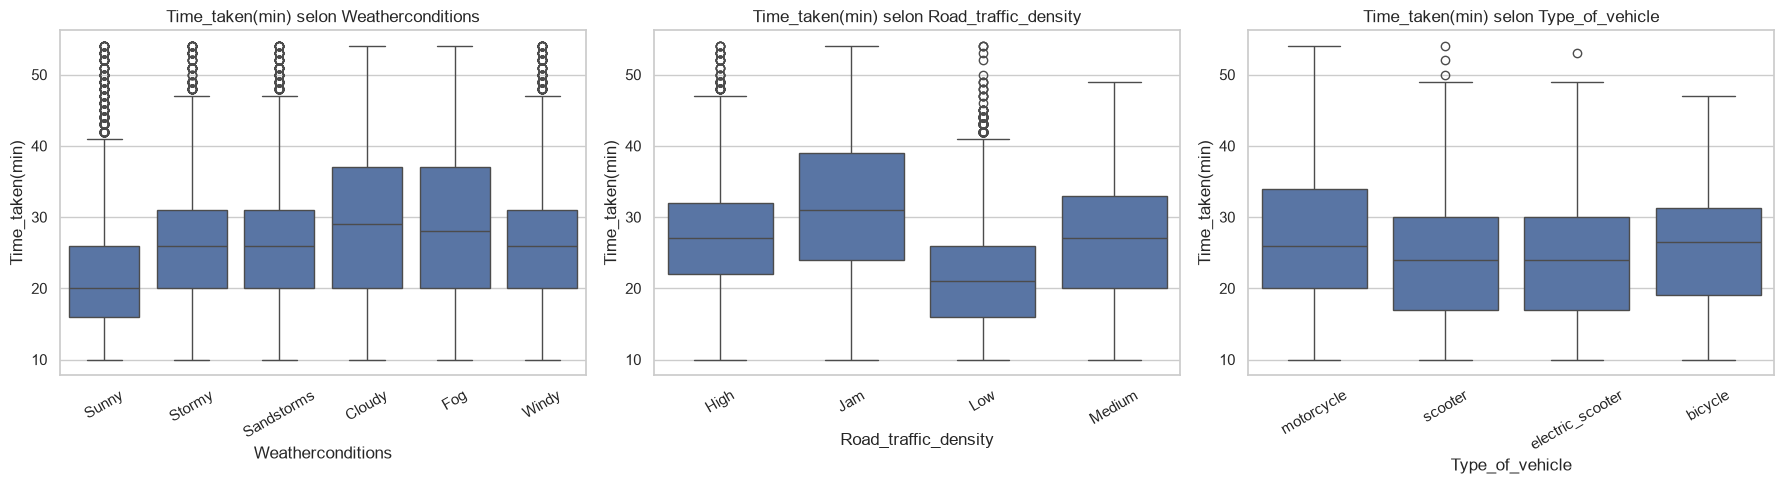

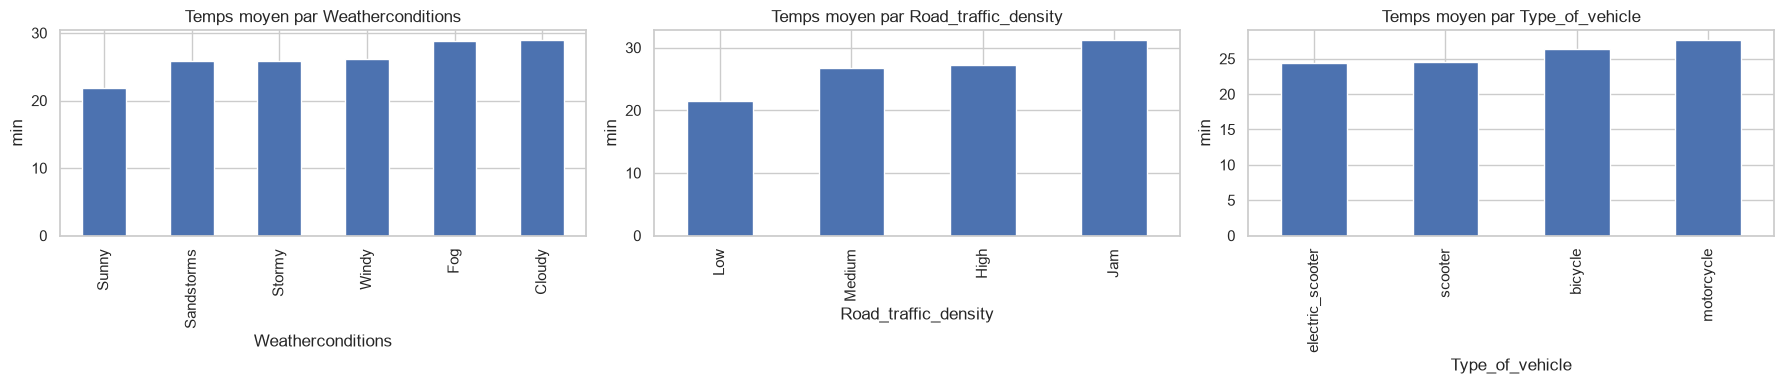

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, c in zip(axes, cat_cols):
    sns.boxplot(data=df, x=c, y="Time_taken(min)", ax=ax)
    ax.set_title(f"Time_taken(min) selon {c}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, c in zip(axes, cat_cols):
    df.groupby(c)["Time_taken(min)"].mean().sort_values().plot(kind="bar", ax=ax)
    ax.set_title(f"Temps moyen par {c}")
    ax.set_ylabel("min")
plt.tight_layout()
plt.show()